In [1]:
# We will now be importing some required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Loading the dataset
dataset = pd.read_csv('drive/MyDrive/SEIS763ML/DataML/carPurchase.csv')

X = dataset.iloc[:,[2,3]].values
y = dataset.iloc[:,4].values

#Splitting the data into Training Set and Test Set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, stratify=y)

#Normalizing the features
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)


In [2]:

#Fitting Classifier to Training Set
from sklearn.ensemble import  AdaBoostClassifier
classifierObj = AdaBoostClassifier()
classifierObj.fit(X_train, y_train)


AdaBoostClassifier()

In [4]:

#Fitting Classifier to Training Set
from sklearn.ensemble import  GradientBoostingClassifier
classifierObj = GradientBoostingClassifier()
classifierObj.fit(X_train, y_train)

GradientBoostingClassifier()

In [6]:
#Fitting Classifier to Training Set

!pip install xgboost
from xgboost import XGBClassifier

classifierObj = XGBClassifier()
classifierObj.fit(X_train, y_train)

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [7]:
#Making predictions on the Test Set
y_pred = classifierObj.predict(X_test)

#Print Model Accuracy
print(classifierObj.score(X_test,y_test))

#Evaluating the predictions using a Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

0.8916666666666667
[[69  8]
 [ 5 38]]


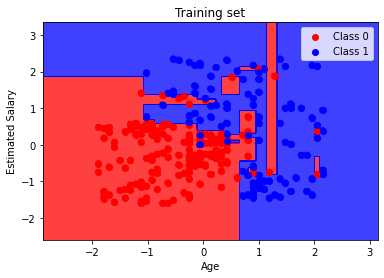

In [ ]:
# Visualizing the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                        np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifierObj.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                alpha = 0.75, cmap = ListedColormap(('red', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'blue')))
plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], color = 'red', label = 'Class 0')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], color = 'blue', label = 'Class 1')
plt.title('Training set')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


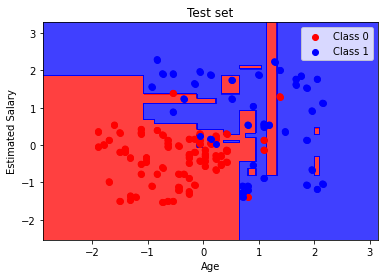

In [ ]:
# Visualizing the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifierObj.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'blue')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'blue')))
plt.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], color = 'red', label = 'Class 0')
plt.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], color = 'blue', label = 'Class 1')
plt.title('Test set')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()